<a href="https://colab.research.google.com/github/Zajecia-na-PWr-LR/lista7-PJ0506/blob/main/zadanie.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import pandas as pd
import numpy as np
from scipy.io import arff
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn import metrics
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.cluster import AgglomerativeClustering
import time

In [3]:
data, meta = arff.loadarff('Dry_Bean_Dataset.arff')

df = pd.DataFrame(data)

for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
print(df.head())

      Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
0  28395.0    610.291       208.178117       173.888747      1.197191   
1  28734.0    638.018       200.524796       182.734419      1.097356   
2  29380.0    624.110       212.826130       175.931143      1.209713   
3  30008.0    645.884       210.557999       182.516516      1.153638   
4  30140.0    620.134       201.847882       190.279279      1.060798   

   Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
0      0.549812     28715.0     190.141097  0.763923  0.988856   0.958027   
1      0.411785     29172.0     191.272750  0.783968  0.984986   0.887034   
2      0.562727     29690.0     193.410904  0.778113  0.989559   0.947849   
3      0.498616     30724.0     195.467062  0.782681  0.976696   0.903936   
4      0.333680     30417.0     195.896503  0.773098  0.990893   0.984877   

   Compactness  ShapeFactor1  ShapeFactor2  ShapeFactor3  ShapeFactor4  Class  
0     0.913358    

In [ ]:
print(df.describe().round(2))

            Area  Perimeter  MajorAxisLength  MinorAxisLength  AspectRation  \
count   13611.00   13611.00         13611.00         13611.00      13611.00   
mean    53048.28     855.28           320.14           202.27          1.58   
std     29324.10     214.29            85.69            44.97          0.25   
min     20420.00     524.74           183.60           122.51          1.02   
25%     36328.00     703.52           253.30           175.85          1.43   
50%     44652.00     794.94           296.88           192.43          1.55   
75%     61332.00     977.21           376.50           217.03          1.71   
max    254616.00    1985.37           738.86           460.20          2.43   

       Eccentricity  ConvexArea  EquivDiameter    Extent  Solidity  roundness  \
count      13611.00    13611.00       13611.00  13611.00  13611.00   13611.00   
mean           0.75    53768.20         253.06      0.75      0.99       0.87   
std            0.09    29774.92          59.1

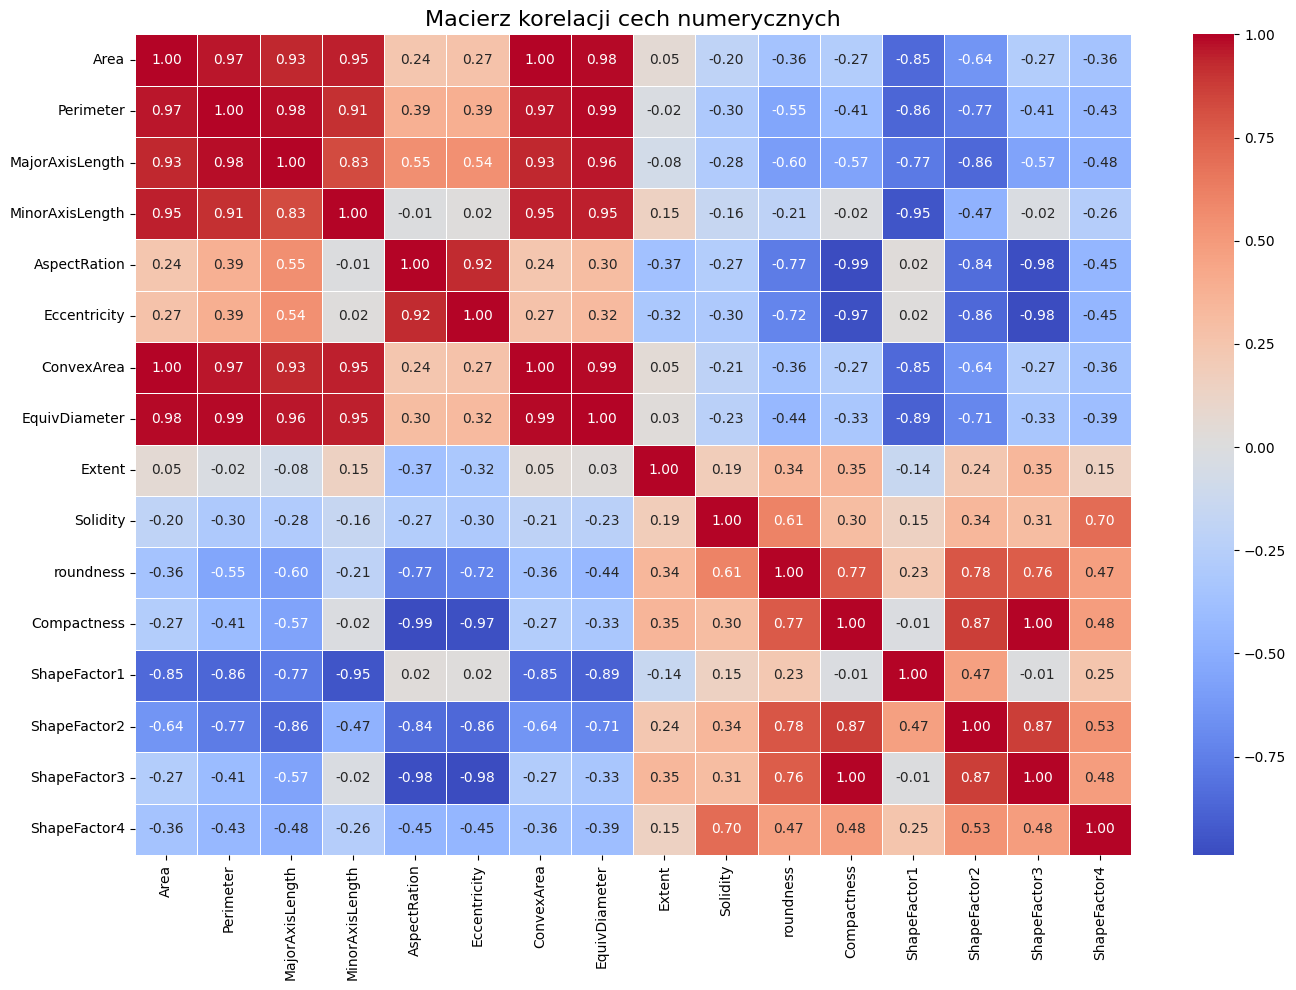

ZBEDNE TZN USUNAC:

['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3']


In [ ]:
numeric_df = df.drop(columns=['Class'])
corr_matrix = numeric_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Macierz korelacji cech numerycznych', fontsize=16)
plt.tight_layout()
plt.show()

print("ZBEDNE TZN USUNAC:\n")
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = [column for column in upper_tri.columns if any(upper_tri[column].abs() > 0.95)]
print(high_corr)

In [4]:
columns_to_drop = ['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3']

df_dropped = df.drop(columns=columns_to_drop)
numeric_df = df_dropped.drop(columns=['Class'])
corr_matrix_v2 = numeric_df.corr().abs()

mask = np.triu(np.ones(corr_matrix_v2.shape), k=1).astype(bool)
upper_tri = corr_matrix_v2.where(mask)

pairs = upper_tri.stack().reset_index()
pairs.columns = ['Cecha_1', 'Cecha_2', 'Korelacja']

best_pairs_for_plots = pairs.sort_values(by='Korelacja', ascending=True)

print("Niska korelacja:")
print(best_pairs_for_plots.head(5))

Niska korelacja:
         Cecha_1       Cecha_2  Korelacja
18  Eccentricity  ShapeFactor1   0.019920
12  AspectRation  ShapeFactor1   0.024593
2           Area        Extent   0.054345
23        Extent  ShapeFactor1   0.141616
25        Extent  ShapeFactor4   0.148502


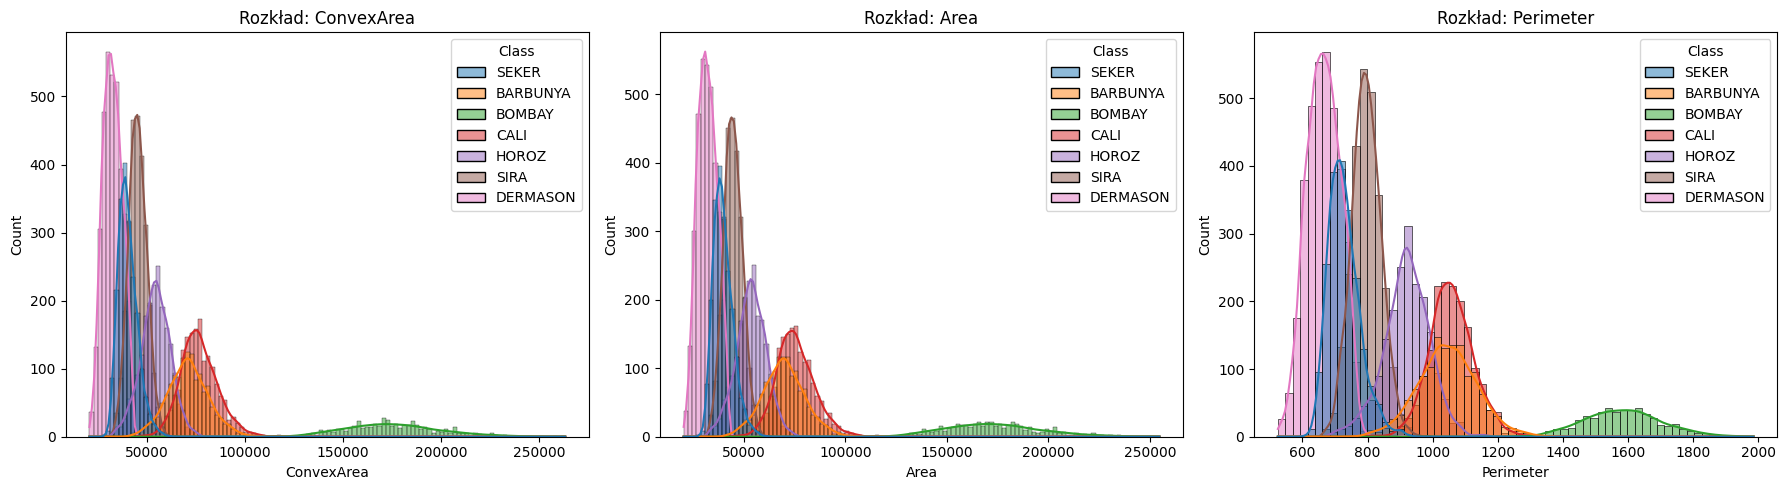

In [ ]:
df_class_out = df.drop(columns=['Class'])
stats = pd.DataFrame({
    'std': df_class_out.std(),
    'skew': df_class_out.skew().abs()
}).sort_values(by='std', ascending=False)

top_features = stats.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feature in enumerate(top_features):
    sns.histplot(data=df, x=feature, hue="Class", kde=True, ax=axes[i])
    axes[i].set_title(f'Rozkład: {feature}')

plt.tight_layout()
plt.show()

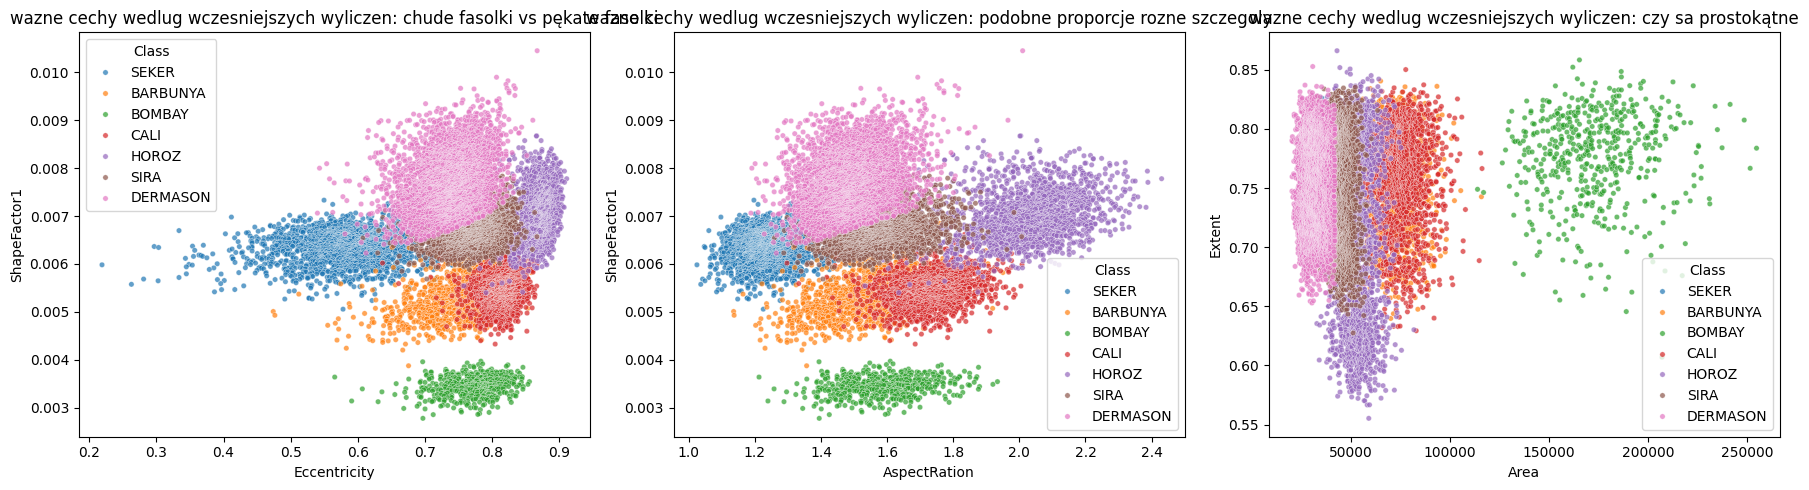

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df_dropped, x='Eccentricity', y='ShapeFactor1', hue='Class', ax=axes[0], palette='tab10', s=15, alpha=0.7)
axes[0].set_title('wazne cechy wedlug wczesniejszych wyliczen: chude fasolki vs pękate fasolki')

sns.scatterplot(data=df_dropped, x='AspectRation', y='ShapeFactor1', hue='Class', ax=axes[1], palette='tab10', s=15, alpha=0.7)
axes[1].set_title('wazne cechy wedlug wczesniejszych wyliczen: podobne proporcje rozne szczegoly')

sns.scatterplot(data=df_dropped, x='Area', y='Extent', hue='Class', ax=axes[2], palette='tab10', s=15, alpha=0.7)
axes[2].set_title('wazne cechy wedlug wczesniejszych wyliczen: czy sa prostokątne')

plt.tight_layout()
plt.show()

In [6]:
columns_to_drop = ['Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'ConvexArea', 'EquivDiameter', 'Compactness', 'ShapeFactor3']

df_dropped = df.drop(columns=columns_to_drop)
new_df = df_dropped.drop(columns=['Class'])
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(new_df), columns=new_df.columns)

In [33]:
kmeans = KMeans(n_clusters=4)
kmeans.fit(df_scaled)
df['Cluster'] = kmeans.fit_predict(df_scaled)

inertia = kmeans.inertia_
print(f"iniercja {inertia:.2f}")
labels = kmeans.labels_

iniercja 55143.35


In [38]:
#napisane wedlug zadania
def visualize_clusters(data_scaled, labels):
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data_scaled)

    plt.figure(figsize=(10, 6))

    sns.scatterplot(x=data_2d[:, 0], y=data_2d[:, 1], hue=labels, palette='viridis', alpha=0.6, s=30)

    plt.title("Wykres")
    plt.xlabel("Skladnik 1")
    plt.ylabel("Skladnik 2")
    plt.legend(title="Klaster")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

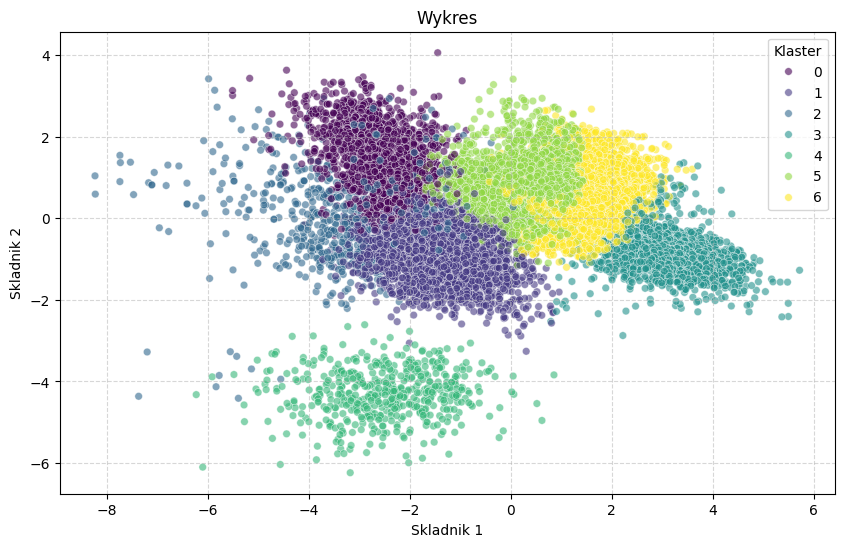

In [39]:
visualize_clusters(df_scaled, labels)

In [8]:
def purity_score(labels_true: np.ndarray, labels_pred: np.ndarray) -> float:
    # 1. Oblicz macierz contingency (podobna do macierzy pomyłek - doczytaj)
    # Jej wiersze odpowiadają klasom (Y), a kolumny klastrom (przewidzianym)
    cont_matrix = metrics.cluster.contingency_matrix(labels_true, labels_pred)

    # 2. Dla każdego klastra oblicz maksymalną liczbę należących do niego przykładów z jednej klasy
    max_per_cluster = np.max(cont_matrix, axis=0)

    # 3. Zsumuj te maksymalne wartości i podziel przez całkowitą liczbę przykładów
    return np.sum(max_per_cluster) / np.sum(cont_matrix)

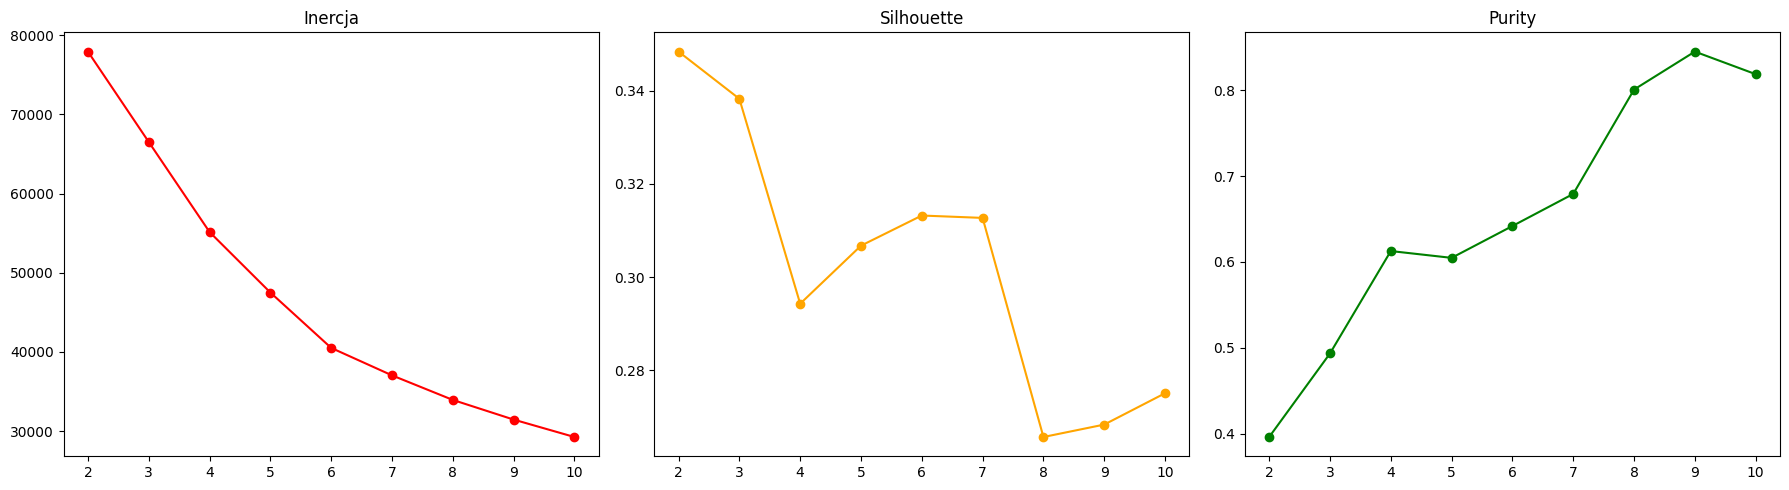

In [11]:
k_range = range(2, 11)
inertias = []
silhouettes = []
purities = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_scaled)

    # Iniercja (god dunno how to write it let it be song)
    inertias.append(kmeans.inertia_)

    # Silhouette
    silhouettes.append(silhouette_score(df_scaled, labels))

    # Purity
    purities.append(purity_score(df['Class'].values, labels))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(k_range, inertias, marker='o', color='red')
axes[0].set_title('Inercja')
axes[1].plot(k_range, silhouettes, marker='o', color='orange')
axes[1].set_title('Silhouette')
axes[2].plot(k_range, purities, marker='o', color='green')
axes[2].set_title('Purity')

plt.tight_layout()
plt.show()

In [46]:
#chcemy zalamanie w pierwszym, czyli 5-6-7 sa ok
#chcemy duzo i uwzgledniamy poprzednie wiec 6-7
#dazymy do 1 i uzwgledniamy poprzednie wiec 7 bedzie najlepsze
# wniosek k = 7.

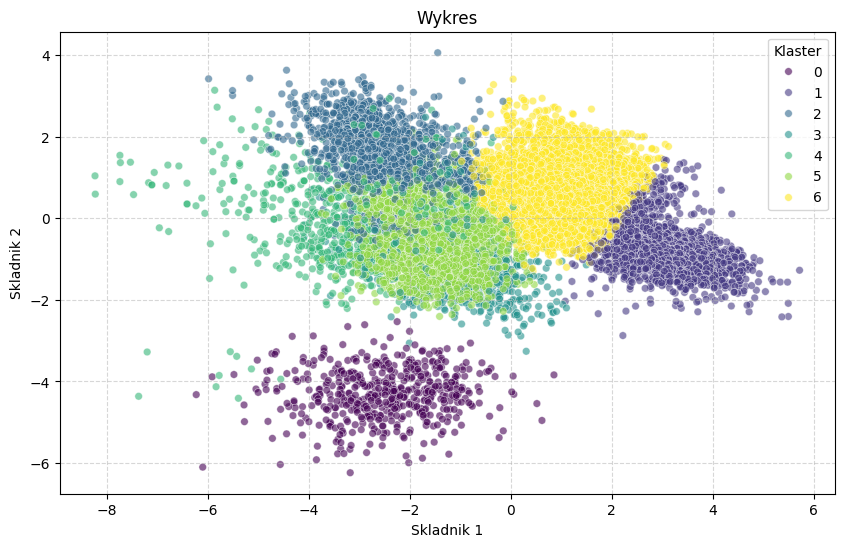

In [48]:
kmeans = KMeans(n_clusters=7)
start_time_km = time.perf_counter()
kmeans.fit(df_scaled)
end_time_km = time.perf_counter()
df['Cluster'] = kmeans.fit_predict(df_scaled)

labels = kmeans.labels_
visualize_clusters(df_scaled, labels)

In [45]:
# NWM czy cos widac ale ok? dla 2 nie bierzemy bo jest mocne rozdzielenie w zbiorze i 2 nam nic nie daje, 7 jest ciekawe bo
#pokazuje ze k-means samemu odkryl ilosc grup w zbiorze, czyli tyle grup ile jest fasoli (klasa docelowa 'Class')

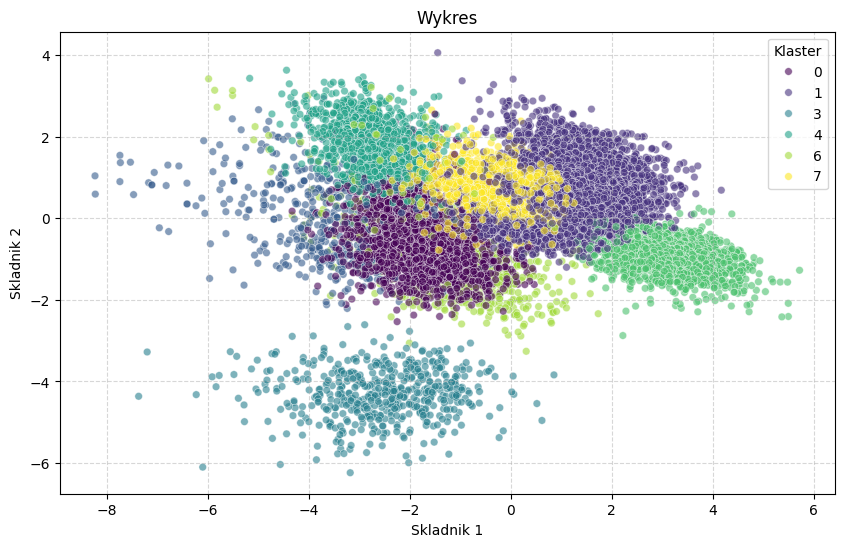

Purity: 0.7570
Silhouette: 0.2438


In [43]:
model_aglo = AgglomerativeClustering(n_clusters=8, linkage='ward')

start_time_ag = time.perf_counter()
labels_aglo = model_aglo.fit_predict(df_scaled)
end_time_ag = time.perf_counter()

visualize_clusters(df_scaled, labels_aglo)

purity_aglo = purity_score(df['Class'].values, labels_aglo)
print(f"Purity: {purity_aglo:.4f}")

sil_aglo = silhouette_score(df_scaled, labels_aglo)
print(f"Silhouette: {sil_aglo:.4f}")


In [44]:
#patrzac na purity i silhoutte 7 znow wygrywa mniej i purity pada, wiecej i silhoutte pada, dla 7 wykresy sa identyczne

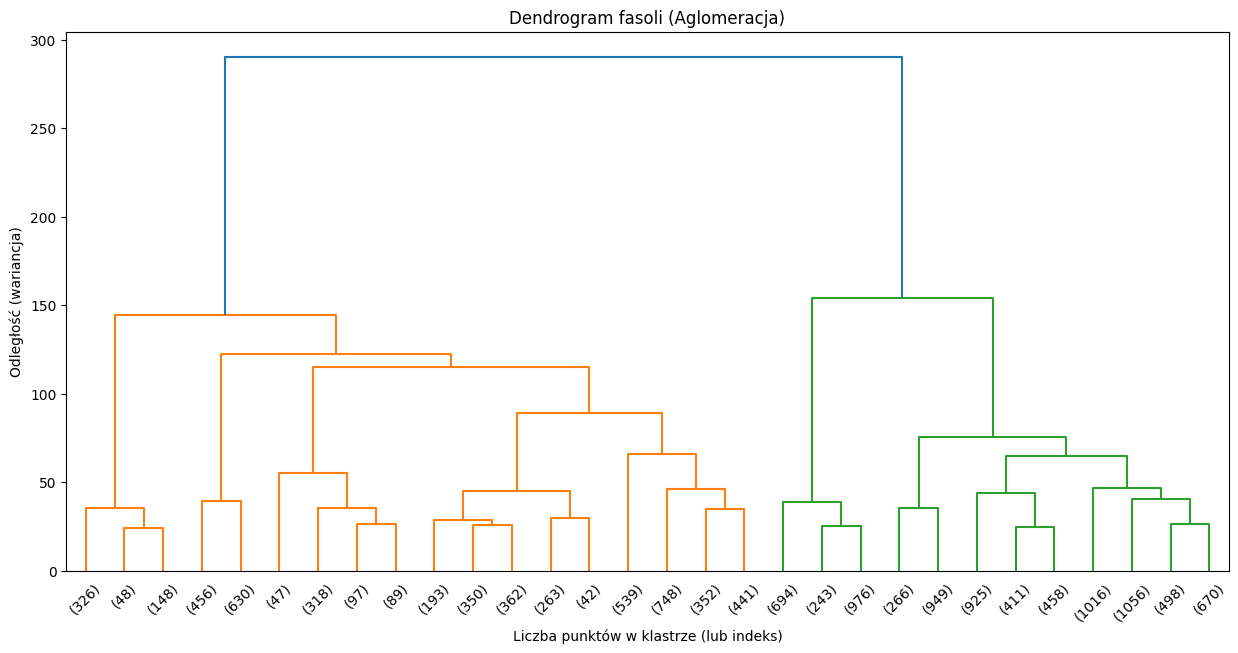

In [22]:
linked = linkage(df_scaled, method='ward')

plt.figure(figsize=(15, 7))
dendrogram(linked, truncate_mode='lastp', p=30)
plt.title("Dendrogram fasoli (Aglomeracja)")
plt.xlabel("Liczba punktów w klastrze (lub indeks)")
plt.ylabel("Odległość (wariancja)")
plt.show()

In [49]:
czas_kmeans = end_time_km - start_time_km
czas_agglo = end_time_ag - start_time_ag

print(czas_kmeans)
print(czas_agglo)

0.05436788000042725
16.5488089749997


In [37]:
#roznica jest spora